### XGBoost Classifier to identify the top predictors of stroke

### Import required libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay
from xgboost import XGBClassifier
import shap
from models import plot_shap_by_confusion_groups

### Load Dataset

In [28]:
# Load data
df = pd.read_csv('../healthcare-dataset-stroke-data.csv')
X = df.drop(columns=['id', 'stroke'])
y = df['stroke']
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [29]:
# Define column groups: numerical, categorical
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                    'work_type', 'Residence_type', 'smoking_status']

### Create preprocessing pipelines

In [30]:
# Numerical: Iterative Imputation
num_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42))
])

# Categorical: Impute missing (if any) and One-Hot Encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine both into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',  # PR-AUC evaluation
    use_label_encoder=False,
    random_state=42
)

# Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

### Hyperparameter tuning

In [31]:
 # Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Hyperparameter grid
param_grid = {
    'classifier__n_estimators': [800, 1200],
    'classifier__max_depth': [2, 3, 4],
    'classifier__learning_rate': [0.01, 0.03, 0.05],
    'classifier__sample_weight':['balanced'],
    'classifier__min_child_weight': [1, 3],
    'classifier__reg_lambda': [1, 5],
    'classifier__scale_pos_weight': [15, 19],
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV 
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

### Train the model

In [32]:
# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best XGBClassifier Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


c:\DSICertificates\stroke_factors_analysis\team-project\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:25:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "sample_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBClassifier Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 800, 'classifier__reg_lambda': 5, 'classifier__sample_weight': 'balanced', 'classifier__scale_pos_weight': 15}


### Obtain the best model

In [33]:
# Get the Best Model from the GridSearch
best_model = grid_search.best_estimator_

# Get Predicted Probabilities
# For highly imbalanced data set, using predict_proba and adjusting the threshold.
y_proba = best_model.predict_proba(X_test)[:, 1]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Use default threshold

In [34]:
# Apply the 0.5 Threshold
y_pred_default = (y_proba >= 0.5).astype(int)
print(f"Best Parameters: {grid_search.best_params_}")
print("\nClassification Report (Pipeline + GridSearch):")
print(classification_report(y_test, y_pred_default))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_pred_default))
pr_auc_default = average_precision_score(y_test, y_proba)
print("XGBoost Forest PR-AUC:", pr_auc_default)
recall_default = recall_score(y_test, y_pred_default)
print("Recall for class 1:", recall_default)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_default))

Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 800, 'classifier__reg_lambda': 5, 'classifier__sample_weight': 'balanced', 'classifier__scale_pos_weight': 15}

Classification Report (Pipeline + GridSearch):
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.15      0.82      0.26        50

    accuracy                           0.77      1022
   macro avg       0.57      0.79      0.56      1022
weighted avg       0.95      0.77      0.83      1022

XGBoost ROC-AUC: 0.7922016460905349
XGBoost Forest PR-AUC: 0.2584266827287345
Recall for class 1: 0.82
Confusion matrix:
 [[743 229]
 [  9  41]]


Recall, also known as sensitivity, focuses on finding all the true positives. In healthcare, missing a positive case, like failing to detect a disease, can be catastrophic. That's why recall often matters more than precision in medical applications. There's always a trade-off between precision and recall.
For the default threshold = 0.5, the XGBoost model detected only 41 out of 50 patients for default threshold = 0.5, also the recall value is good at 0.82. 

### Use best threshold for recall metric

In [35]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
target_recall = recall_default
if recall_default < 0.8:
    recall_default = 0.8
# thresholds array is one shorter than recall
thresholds = np.append(thresholds, 1.0)
# find candidates
idx = np.where(recall >= target_recall)[0]
best_threshold = thresholds[idx[-1]]  # highest threshold meeting recall
print("Best threshold:", best_threshold)

# Apply the best_threshold
y_pred = (y_proba >= best_threshold).astype(int)
print(f"Best Parameters: {grid_search.best_params_}")
print("\nClassification Report (Pipeline + GridSearch):")
print(classification_report(y_test, y_pred))
print("XGBoost Forest ROC-AUC:", roc_auc_score(y_test, y_pred))
print("XGBoost Forest PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall for class 1:", recall_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Best threshold: 0.5117176175117493
Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 800, 'classifier__reg_lambda': 5, 'classifier__sample_weight': 'balanced', 'classifier__scale_pos_weight': 15}

Classification Report (Pipeline + GridSearch):
              precision    recall  f1-score   support

           0       0.99      0.77      0.87       972
           1       0.16      0.82      0.26        50

    accuracy                           0.77      1022
   macro avg       0.57      0.80      0.57      1022
weighted avg       0.95      0.77      0.84      1022

XGBoost Forest ROC-AUC: 0.7963168724279834
XGBoost Forest PR-AUC: 0.2584266827287345
Recall for class 1: 0.82
Confusion matrix:
 [[751 221]
 [  9  41]]


Important Notes for Imbalanced Data
- ROC AUC can still look high even if the model fails to detect rare positives.
- For 5% positive medical dataset, it’s better to also look at PR AUC (Precision-Recall AUC), because it focuses on positive class performance

### Predicted class distributions

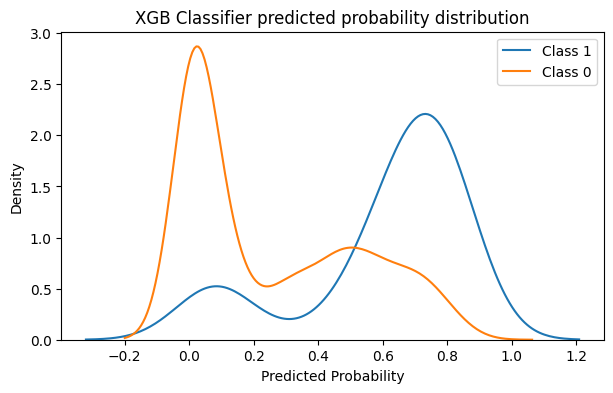

In [36]:
plt.figure(figsize=(7,4))
sns.kdeplot(y_proba[y_test==1], label="Class 1")
sns.kdeplot(y_proba[y_test==0], label="Class 0")
plt.title("XGB Classifier predicted probability distribution")
plt.xlabel("Predicted Probability")
plt.legend()
plt.savefig(f"images/XGBClassifier_predicted_probability_distribution.png", bbox_inches="tight")
plt.show()

### The confusion matrix

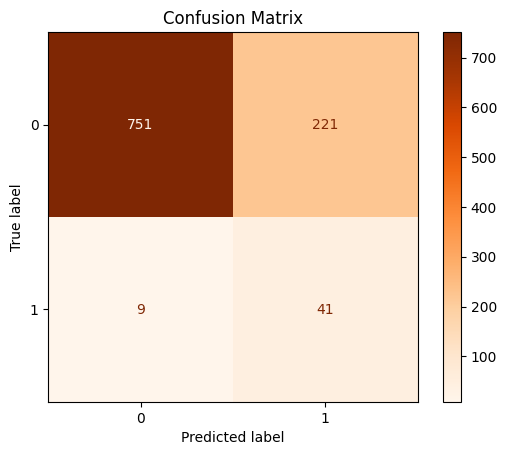

In [37]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix")
plt.savefig(f"images/XGBClassifier_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Precision-Recall Curve

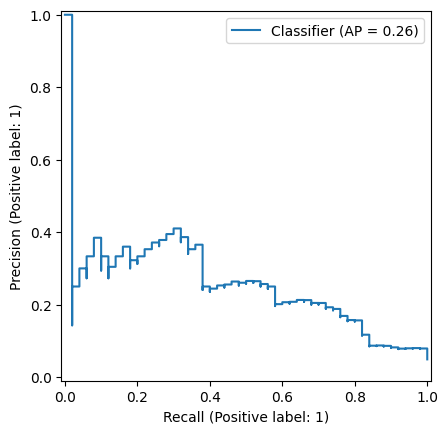

In [38]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba)
display.ax_.legend(loc="upper right")
plt.show()

### Top ten important features

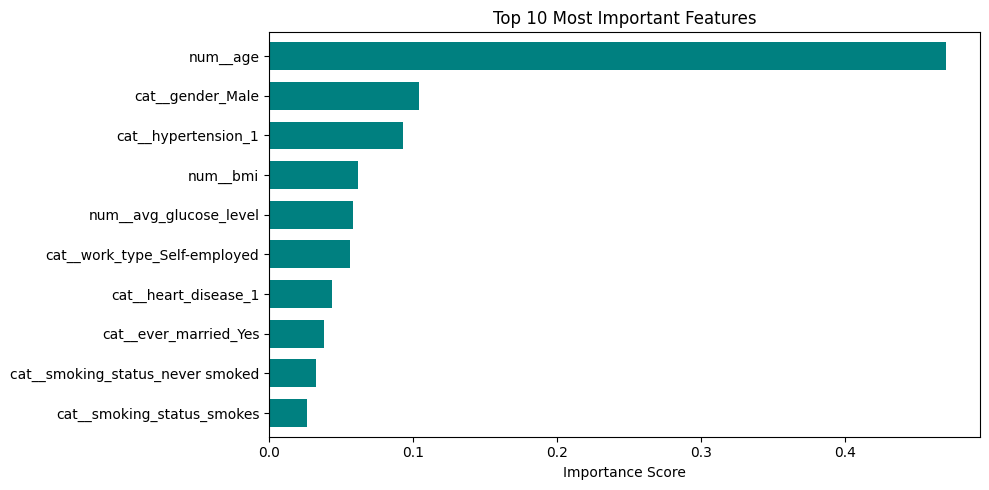

In [39]:
plt.figure(figsize=(10, 5))
# Extracting feature names 
all_feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
# Get Importance from the classifier inside the pipeline
importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).nlargest(10)

feat_imp.sort_values().plot(kind='barh', color='teal', width=0.7)
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.savefig(f"images/XGBClassifier_top_10_most_important_features.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

### SHAP Analysis

In [40]:
# Extract classifier from pipeline
best_pipeline = grid_search.best_estimator_
best_classifier = best_pipeline.named_steps['classifier']

# Transform test set
preprocessor = best_pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)
X_train_transformed = preprocessor.transform(X_train)

# Get correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame for SHAP
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)

# Compute SHAP values
explainer = shap.TreeExplainer(model=best_classifier, 
                               data= X_train_transformed_df, 
                               feature_perturbation="interventional",
                               model_output="probability")

shap_values = explainer(X_test_transformed_df)

### SHAP plots

In this notebook, we are using 3 SHAP plots.
#### Beeswarm Plot (Healthcare/Stroke Context)

The SHAP beeswarm plot shows how key features—such as age, average glucose level, and BMI—affect stroke risk across all patients. Each dot represents one patient, positioned by the feature’s impact on the prediction (left decreases risk, right increases risk) and colored by the feature value (low to high). This visualization highlights the direction, strength, and variability of important clinical factors driving stroke risk at the population level.

#### Bar Plot (Healthcare/Stroke Context)

The SHAP bar plot shows the overall importance of each feature in predicting stroke risk across the patient population. Bars represent the average magnitude of impact (mean absolute SHAP value), with longer bars indicating features that influence the model most strongly. This plot is useful for identifying the key clinical factors driving stroke predictions at the population level.

#### waterfall plots

The SHAP waterfall plot explains an individual patient’s prediction by showing how each feature (e.g., age, glucose level, BMI) shifts the model output from the baseline risk to the final stroke risk score. Features pushing risk higher appear to the right, while those lowering risk appear to the left. The bar lengths indicate the strength of each factor’s influence. This plot is especially useful for understanding why the model flagged or missed stroke risk for a specific patient.


Group sizes:
TP: 41
TN: 751
FP: 221
FN: 9

===== TP =====


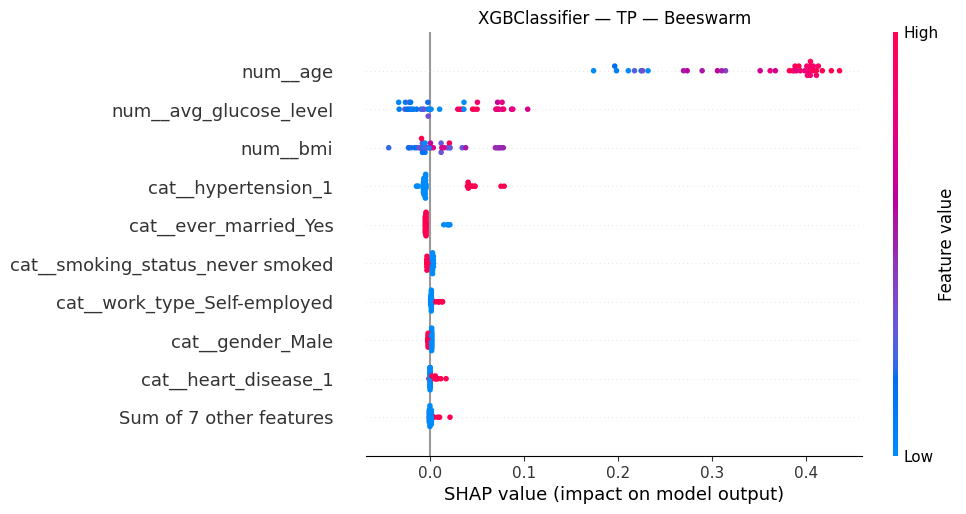

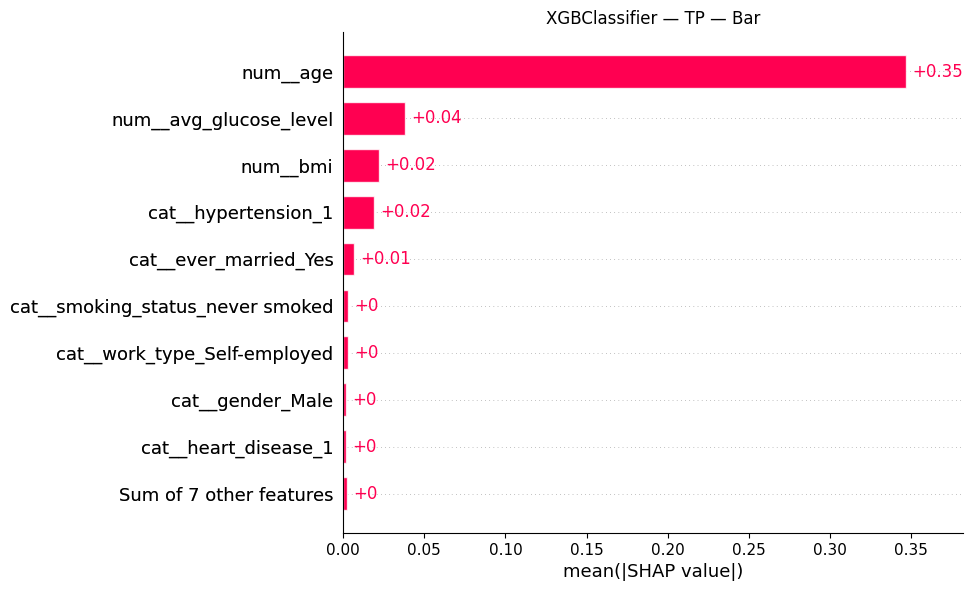

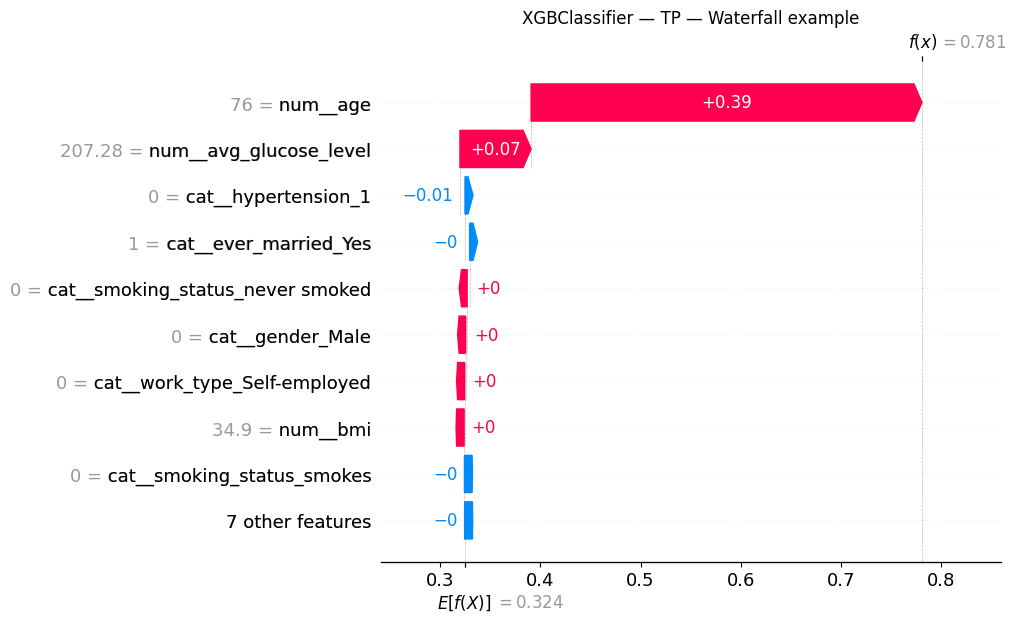


===== TN =====


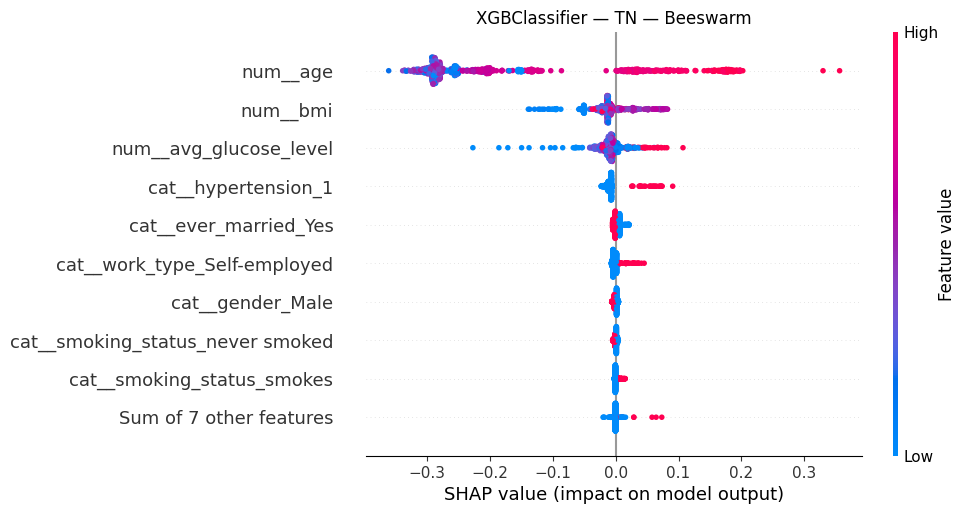

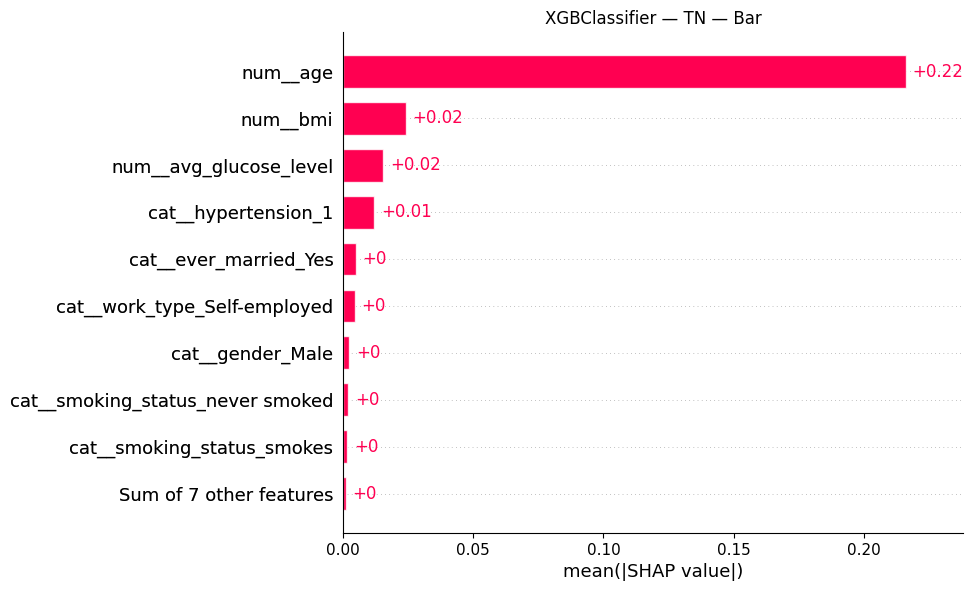

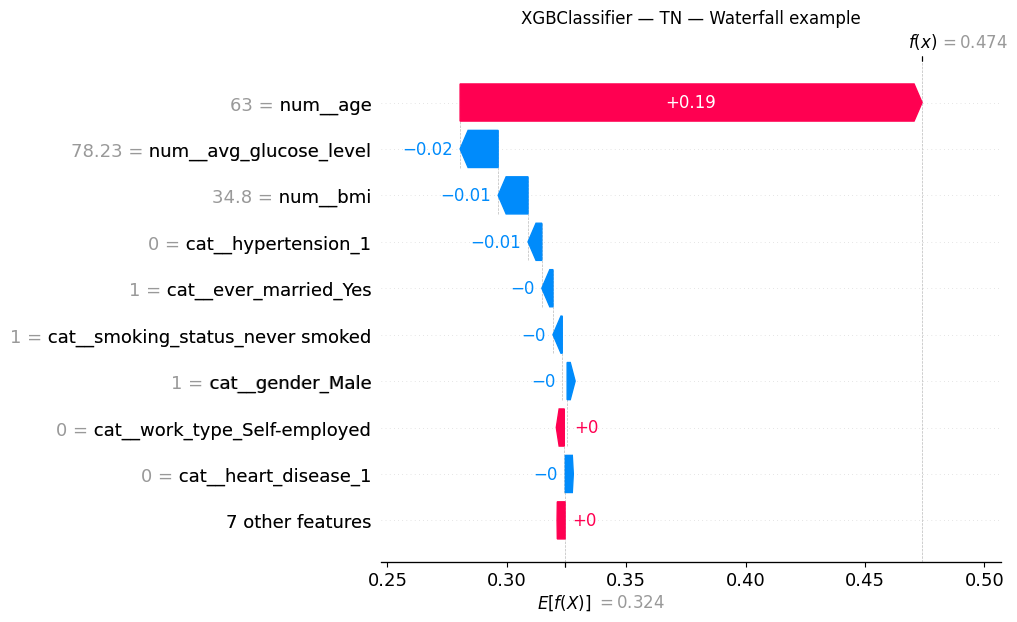


===== FP =====


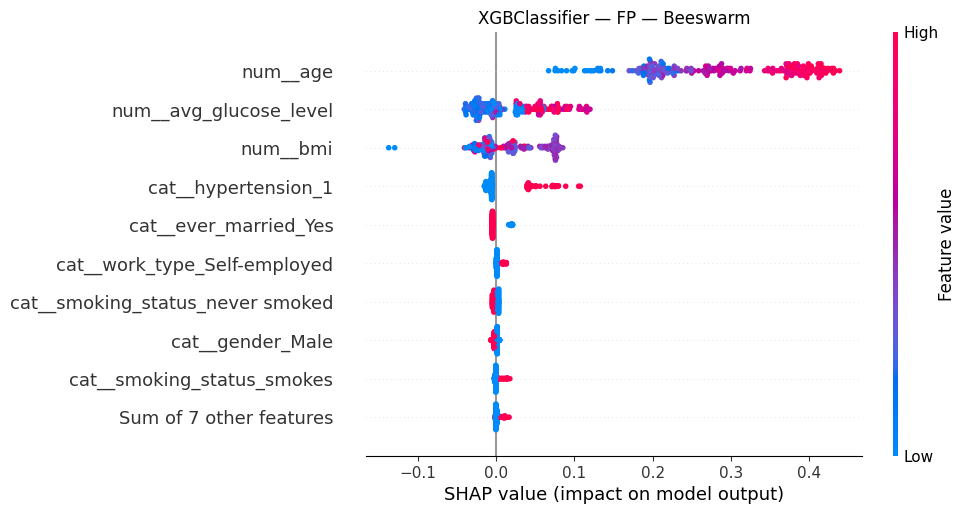

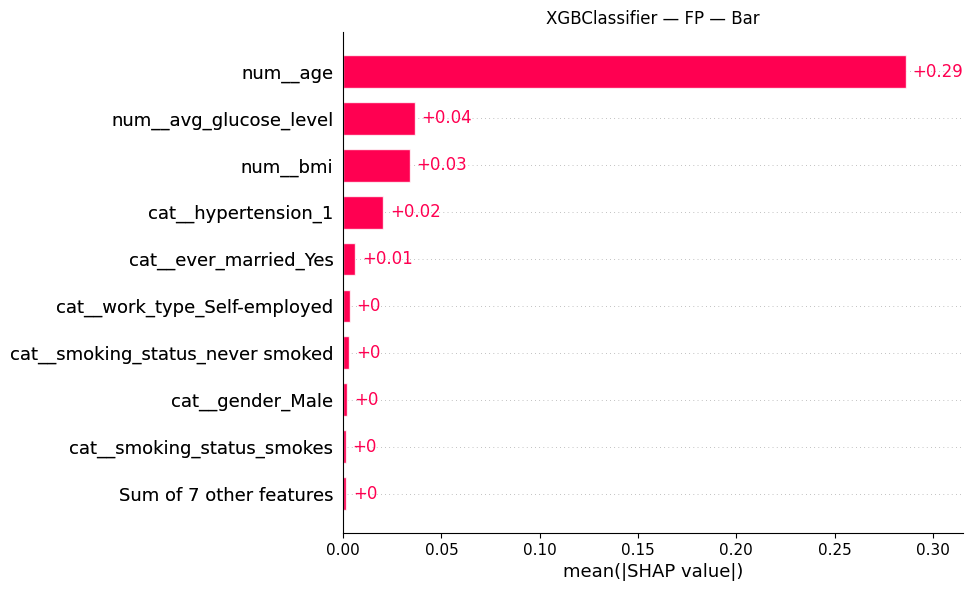

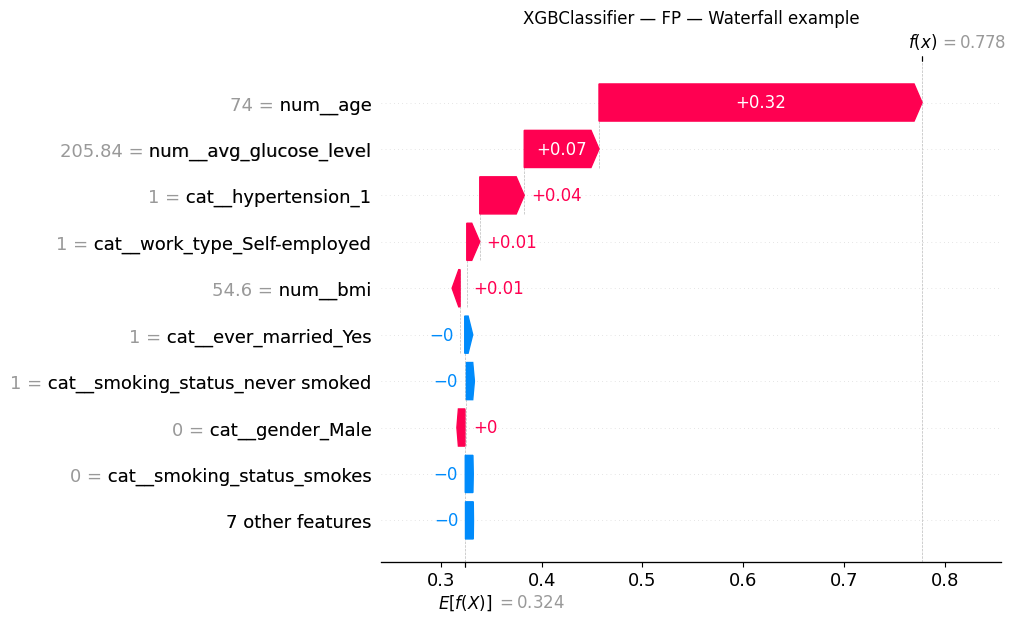


===== FN =====


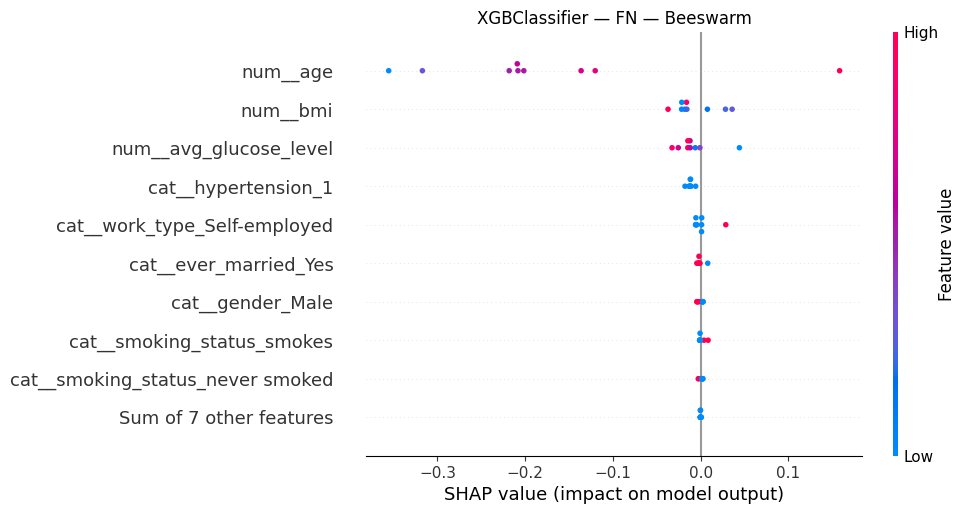

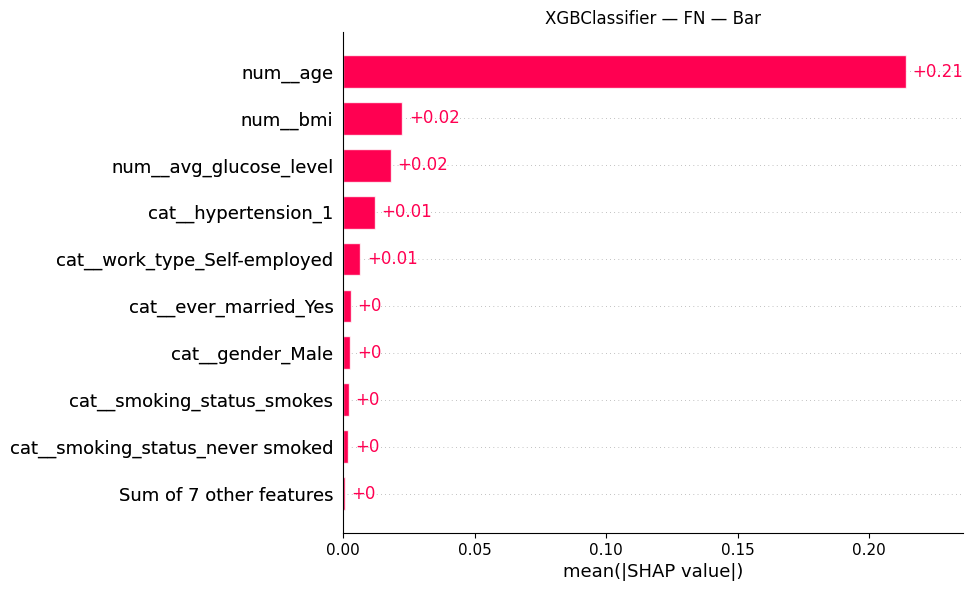

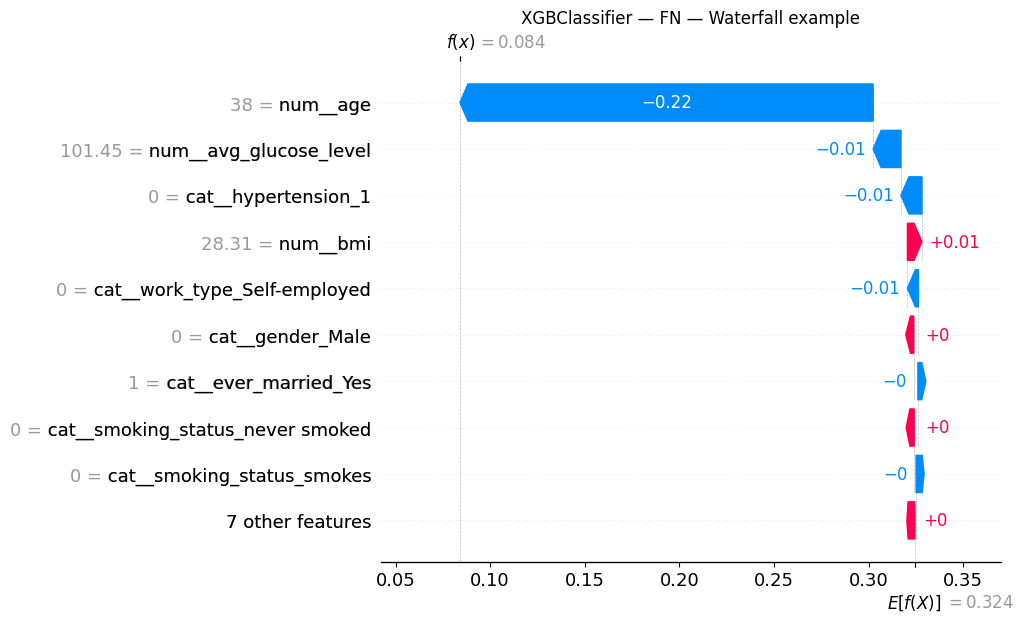

In [41]:
plot_shap_by_confusion_groups(
    model=best_classifier,
    shap_values=shap_values,
    y_true=y_test,
    y_pred=y_pred
)

### 14. Insights from Beeswarm plots:

True Positive - TP:

The top features age, average glucose level, and bmi are the most important. Patients of all ages, old (red dots) or young (blue dots) are displayed correctly above the average line. Patients glucose level is moderate, i.e. clustered around the average line. Hypertension in fourth place is showing strong sign towards class1 as well. These 4 features together have a stronger effect on the prediction towards Class1.

True Negative - TN:

The same 3 features are on top, but bmi is second, and average glucose level is third. Patients in this group are mostly young. The plot showing a very young group (blue color) to the left of the average line and displayed correctly below the average line. Patients glucose level is moderate, i.e. clustered around the average line with a good number showing strong pull to Class0. Hypertension in fourth place is showing strong sign towards class1 as well. These 3 features together have a stronger effect on the prediction towards Class0.

False Positive - FP:

The same 3 features are on top, average glucose level, and bmi. Patients in this group are mostly old. There are 2 big clusters, one cluster for old patients (mix red, and blue), and the second cluster for much older patients ( red color). It is clear the cluster for older patients pulling towards Class 1. These second feature average glucose level showed a good number to the right (red color) of the average line. The third feature is more clustred close to the aveage line. The first 2 features together have a stronger effect on the prediction towards Class1. The age cluster for much older patients all red is a good indication that the model is predicting a stroke whether this is the case or not.


False Negative - FN:

The same 3 features are on top, but bmi is second, and average glucose level is third. Patients in this group are mostly young left of the average line as per age feature. The age color for these patient is red i.e. identified Class1 correclty. However all other features identify these patients as Class 0 (blue dots). Looking at the graph since age feature assign Class1, and the other feature assign Class0, the probabilty for these patients is very close to the thresold. It i very likely that more calibration to threshold would assign these patients to Class1.

In conclusion, the model is mainly driven by age, glucose, and BMI. Categorical features (marital status, hypertension) matter but less.
